In [1]:
import os 
cwd = os.getcwd()
cwd

os.chdir("/Users/jmthomas565/Desktop/Education/Applied Stats MSc/MSc Project/Git Files/msc-project-source-code-files-24-25-jmthomas565/Code/Project Code Pipeline")

new_cwd = os.getcwd() 

new_cwd


'/Users/jmthomas565/Desktop/Education/Applied Stats MSc/MSc Project/Git Files/msc-project-source-code-files-24-25-jmthomas565/Code/Project Code Pipeline'

In [2]:
%run 00_inititial_transformations.ipynb

['2017-07-01', '2017-07-02', '2017-07-03', '2017-07-04', '2017-07-05'] ... ['2022-09-27', '2022-09-28', '2022-09-29', '2022-09-30', '2022-10-01']


### Testing for Stationarity

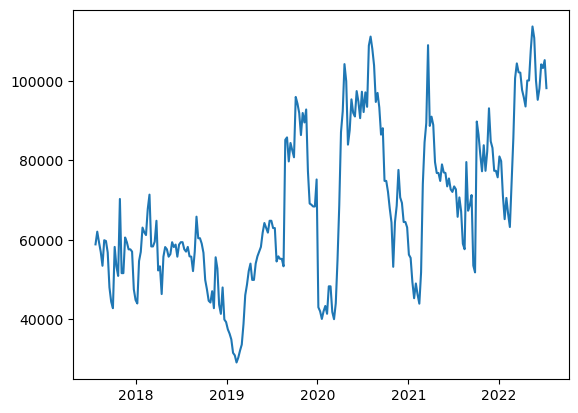

In [4]:
#Plotting the response variable, to test for stationarity

plt.figsize=(10,5)
plt.plot(bike_sales_data['sales'])
plt.show()

In [5]:
#Testing for stationarity with the ADF test

from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(bike_sales_data['sales'])
adf_test

(-2.905903189866598,
 0.04466583063931011,
 0,
 259,
 {'1%': -3.4558530692911504,
  '5%': -2.872764881778665,
  '10%': -2.572751643088207},
 5009.784781976807)

In [6]:
print ("p-value:", adf_test[1])

#We reject the null, but the plot clearly shows that it's not stationary.

p-value: 0.04466583063931011


In [7]:
bike_sales_data_stationary = bike_sales_data

In [8]:
#Taking the 1st difference of the response

bike_sales_data_stationary['sales'] = bike_sales_data_stationary['sales'].diff()

bike_sales_data_stationary.dropna(inplace=True)

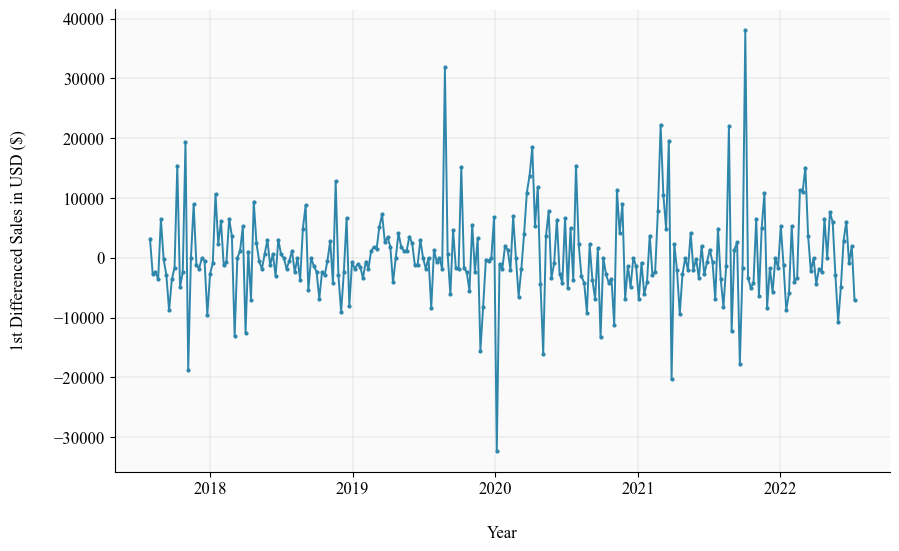

In [24]:
#Plotting the 1st differenced response

fig, ax = plt.subplots(figsize = (10, 6))

plt.plot(bike_sales_data_stationary['sales'], linestyle = 'solid', marker = 'o', markersize=2, linewidth = '1.4', c='#2E86AB')

plt.rcParams['font.family'] = 'Times New Roman'

ax.xaxis.set_tick_params(labelsize=10)

ax.yaxis.set_tick_params(labelsize=10)


ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', which='major', labelsize=12, width=0.8)
ax.tick_params(axis='both', which='minor', labelsize=10, width=0.5)


ax.xaxis.labelpad=20

ax.yaxis.labelpad=20

ax.set_facecolor('#fafafa')

ax.grid (color='grey', linestyle='-', linewidth=0.25, alpha=0.5)

ax.set_xlabel('Year', fontsize = 12)
ax.set_ylabel('1st Differenced Sales in USD ($)', fontsize = 12)

plt.show()

In [10]:
adf_test = adfuller(bike_sales_data_stationary['sales'])
adf_test

print("p-value:", adf_test[1])

#Has now gone very low, which supports the plot.

p-value: 1.8437974308035753e-29


In [11]:
y_train = y_train.diff()

y_train.dropna(inplace=True)

In [12]:
#Removing the first row of X_train so it aligns with Y_train

X_train = X_train.iloc[1:]